# Exploratory Factor Analysis

### What is Exploratory Factor Analysis (EFA)?

**Exploratory Factor Analysis (EFA)** is a statistical technique used to uncover the underlying structure of a relatively large set of variables. EFA reduces data to a smaller set of summary variables (called **factors**) and helps explore the theoretical structure of the phenomena.

Unlike CFA, EFA does not assume a pre-defined structure. It allows all items to load on all factors.

#### Key Steps in EFA
1.  **Factor Extraction**: Determining how many factors underlie the data (e.g., Eigenvalues > 1, Screen Plot).
2.  **Rotation**: Rotating the axes to achieve a "Simple Structure" (interpretable factors).
    *   **Orthogonal (e.g., Varimax)**: Assumes factors are uncorrelated.
    *   **Oblique (e.g., Promax, Oblimin)**: Assumes factors are correlated (more realistic in psychology).
3.  **Interpretation**: Naming the factors based on high-loading items.

#### The Model
$$ X = \mu + \Lambda F + \epsilon $$
Where $X$ is the data, $\Lambda$ is the loading matrix, $F$ are the factors, and $\epsilon$ is noise.

Observed Data (First 5 rows):
      Item1     Item2     Item3     Item4     Item5     Item6
0 -0.204621  0.749838  0.687235  0.895643  0.372098 -0.068970
1 -0.294283 -0.493304 -0.359281  0.804655  0.332944  0.579557
2  0.628553  0.930762  0.383525  0.955062  1.023665  1.361955
3  1.342596  1.912982  0.775831  0.736570  1.165741  1.329849
4 -0.505116 -0.045364 -0.199939 -0.846262 -1.220358 -0.612780

Factor Loadings (Relationship between Items and Factors):
       Factor_1  Factor_2
Item1     0.681     0.164
Item2     0.890     0.049
Item3     0.650    -0.073
Item4     0.047     0.781
Item5    -0.017     0.880
Item6     0.160     0.742


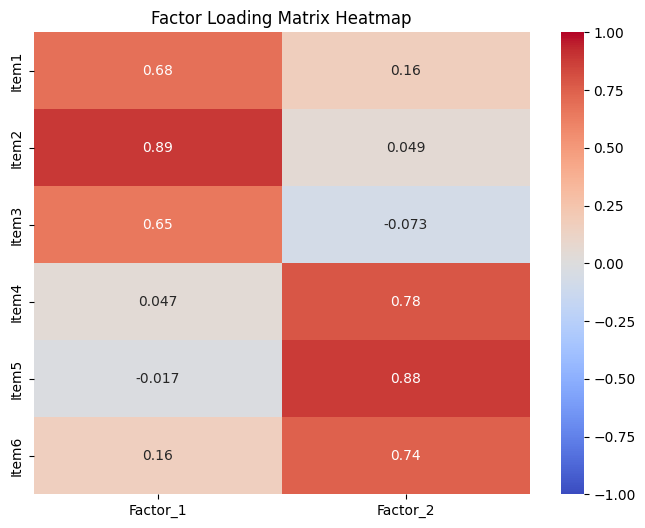

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import FactorAnalysis
from sklearn.preprocessing import StandardScaler

# 1. Toy Data Generation (Pedagogical Example)
# We will create 2 latent factors and 6 observed variables (3 for each factor).
np.random.seed(42)
n_samples = 200

# Generating Latent Factors (uncorrelated for simplicity)
F1 = np.random.normal(0, 1, n_samples) # Factor 1: e.g., "Math Ability"
F2 = np.random.normal(0, 1, n_samples) # Factor 2: e.g., "Verbal Ability"

# Generating Observed Variables (X = Loading*F + Error)
# Items 1-3 load on F1, Items 4-6 load on F2
X1 = 0.8*F1 + 0.1*F2 + np.random.normal(0, 0.4, n_samples)
X2 = 0.9*F1 + 0.0*F2 + np.random.normal(0, 0.4, n_samples)
X3 = 0.7*F1 - 0.1*F2 + np.random.normal(0, 0.4, n_samples)

X4 = 0.1*F1 + 0.8*F2 + np.random.normal(0, 0.4, n_samples)
X5 = 0.0*F1 + 0.9*F2 + np.random.normal(0, 0.4, n_samples)
X6 = 0.2*F1 + 0.7*F2 + np.random.normal(0, 0.4, n_samples)

data = pd.DataFrame({'Item1': X1, 'Item2': X2, 'Item3': X3, 
                     'Item4': X4, 'Item5': X5, 'Item6': X6})

print("Observed Data (First 5 rows):")
print(data.head())

# 2. Run Exploratory Factor Analysis
# Using sklearn FactorAnalysis (Note: sklearn uses SVD/MLE, usually produces orthogonal rotations by default)
# We specify n_components=2 (assuming we decided this from a scree plot)
fa = FactorAnalysis(n_components=2, rotation='varimax', random_state=42)
fa.fit(data)

# 3. Inspect Loadings
loadings = pd.DataFrame(fa.components_.T, 
                        index=data.columns, 
                        columns=['Factor_1', 'Factor_2'])

print("\nFactor Loadings (Relationship between Items and Factors):")
print(loadings.round(3))

# 4. Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(loadings, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Factor Loading Matrix Heatmap")
plt.show()

# Interpretation: 
# Factor 1 likely corresponds to Items 1-3.
# Factor 2 likely corresponds to Items 4-6.